正在读取全市场数据，请稍候...
正在计算 MACD 指标与金叉/死叉信号 (需时约 1-2 分钟)...
开始按日执行【MACD水上加仓+批次止盈】策略模拟...
已回测 0/3935 个交易日...
已回测 500/3935 个交易日...
已回测 1000/3935 个交易日...
已回测 1500/3935 个交易日...
已回测 2000/3935 个交易日...
已回测 2500/3935 个交易日...
已回测 3000/3935 个交易日...
已回测 3500/3935 个交易日...

✅ 回测完成！正在处理结果...
交易明细已成功导出至: F:\self_quant\data\data\MACD水上金叉加仓策略明细.xlsx
💰 初始本金: 50,000.00 元
💰 MACD特定策略最终总资产: 98,896.60 元
📈 策略总收益率: 97.79%


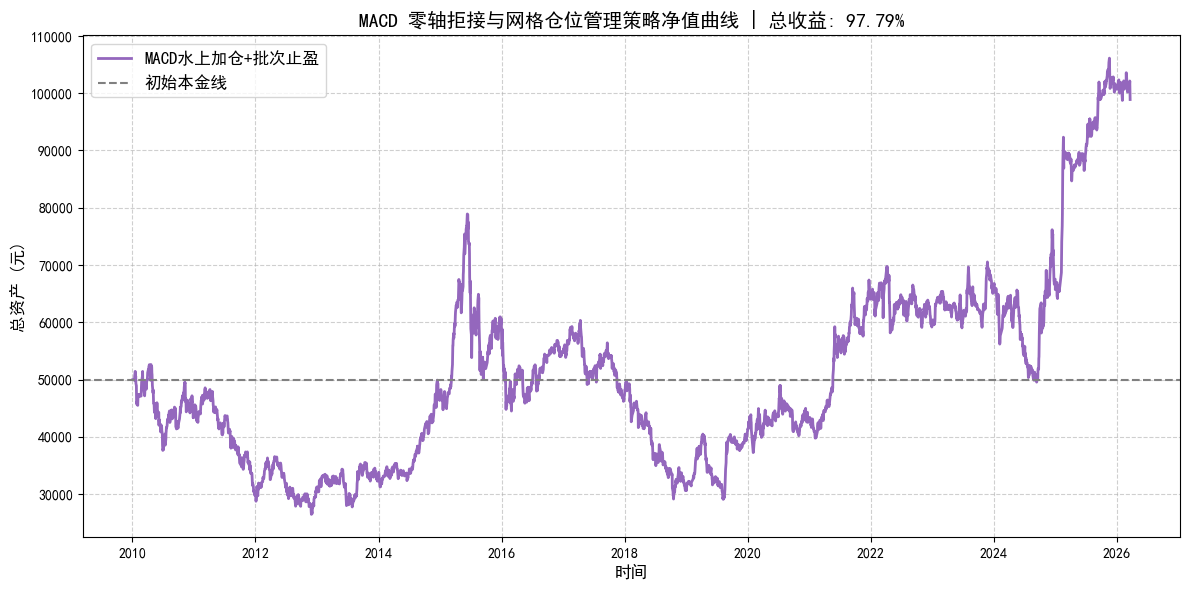

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\data\data\MACD水上金叉加仓策略明细.xlsx"

INITIAL_CASH = 50000.0
# 为了给加仓留有余地，我们把每笔交易的基础金额定为 5000 元
BASE_TRADE_AMOUNT = 5000.0

print("正在读取全市场数据，请稍候...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤主板数据
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

# ==========================================
# 第二步：向量化预计算 MACD 及买卖信号 (极速计算)
# ==========================================
print("正在计算 MACD 指标与金叉/死叉信号 (需时约 1-2 分钟)...")
df.sort_values(by=['code', 'date'], inplace=True)

# 1. 计算 MACD (参数 12, 26, 9)
df['EMA12'] = df.groupby('code')['close'].transform(lambda x: x.ewm(span=6, adjust=False).mean())
df['EMA26'] = df.groupby('code')['close'].transform(lambda x: x.ewm(span=13, adjust=False).mean())
df['DIF'] = df['EMA12'] - df['EMA26']
df['DEA'] = df.groupby('code')['DIF'].transform(lambda x: x.ewm(span=5, adjust=False).mean())
df['MACD'] = (df['DIF'] - df['DEA']) * 2

# 2. 判断金叉与死叉
df['prev_DIF'] = df.groupby('code')['DIF'].shift(1)
df['prev_DEA'] = df.groupby('code')['DEA'].shift(1)

# 金叉：今天 DIF > DEA 且 昨天 DIF <= DEA
df['GC'] = (df['DIF'] > df['DEA']) & (df['prev_DIF'] <= df['prev_DEA'])
# 死叉：今天 DIF < DEA 且 昨天 DIF >= DEA
df['DC'] = (df['DIF'] < df['DEA']) & (df['prev_DIF'] >= df['prev_DEA'])

# 3. 记录上一次金叉时的位置 (水上还是水下)
# 把所有发生金叉当天的 DIF 值提取出来，非金叉日设为 NaN
df['GC_DIF_Value'] = np.where(df['GC'], df['DIF'], np.nan)
# 向下填充，并 shift(1)，这样今天就能知道“上一次金叉的 DIF 值是多少”
df['prev_GC_DIF'] = df.groupby('code')['GC_DIF_Value'].transform(lambda x: x.ffill().shift(1))

# 4. 生成核心买卖信号
# 买入信号：今天发生金叉 & 今天是水上(DIF>0) & 上一次金叉是水下(prev_GC_DIF<0)
df['Buy_Signal'] = df['GC'] & (df['DIF'] > 0) & (df['prev_GC_DIF'] < 0)
# 卖出信号基础：死叉
df['Sell_Signal'] = df['DC']

# ==========================================
# 第三步：定义精细化的批次账户类 (核心重构)
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    return commission + transfer_fee + stamp_duty, amount

class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        # positions 结构: {code: {'batches': [{'price': p, 'vol': v, 'date': d}], 'total_vol': V, 'total_cost': C}}
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []

    def add_batch(self, code, price, vol, date):
        if code not in self.positions:
            self.positions[code] = {'batches': [], 'total_vol': 0, 'total_cost': 0}
        self.positions[code]['batches'].append({'price': price, 'vol': vol, 'date': date})
        self.positions[code]['total_vol'] += vol
        self.positions[code]['total_cost'] += price * vol

    def get_avg_cost(self, code):
        pos = self.positions.get(code)
        if not pos or pos['total_vol'] == 0: return 0
        return pos['total_cost'] / pos['total_vol']

    def remove_all(self, code):
        vol = self.positions[code]['total_vol']
        del self.positions[code]
        return vol

    def remove_last_batch(self, code):
        batch = self.positions[code]['batches'].pop()
        self.positions[code]['total_vol'] -= batch['vol']
        self.positions[code]['total_cost'] -= batch['price'] * batch['vol']
        if len(self.positions[code]['batches']) == 0:
            del self.positions[code]
        return batch

    def get_total_asset(self, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            stock_value += pos['total_vol'] * current_prices_dict.get(code, pos['batches'][-1]['price'])
        return self.cash + stock_value

account = Account(INITIAL_CASH)

# ==========================================
# 第四步：按日执行交易主引擎
# ==========================================
print("开始按日执行【MACD水上加仓+批次止盈】策略模拟...")

grouped = df.groupby('date')
dates = sorted(list(grouped.groups.keys()))
total_days = len(dates)

for i, date in enumerate(dates):
    daily_data = grouped.get_group(date).set_index('code')
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    current_asset = account.get_total_asset(current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    if i % 500 == 0:
        print(f"已回测 {i}/{total_days} 个交易日...")

    # ---------------- 1. 卖出逻辑 (死叉判定) ----------------
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        if code in daily_data.index and daily_data.loc[code, 'Sell_Signal']:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)

            if is_trading and pct_chg > -9.8:
                current_price = current_prices[code]
                avg_cost = account.get_avg_cost(code)

                # 预留千分之三的滑点和费用空间来判定“是否真盈利”
                if current_price > avg_cost * 1.003:
                    # 整体盈利：全部清仓
                    sell_vol = account.remove_all(code)
                    fee, amount = calculate_fees('sell', current_price, sell_vol)
                    account.cash += (amount - fee)

                    account.trade_logs.append({
                        '日期': date, '股票代码': code, '买卖方向': '卖出(整体止盈)',
                        '成交价': current_price, '成交股数': sell_vol,
                        '成交金额': round(amount, 2), '交易费': round(fee, 2),
                        '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(current_prices), 2),
                        '备注': '死叉且整体盈利，全清'
                    })
                else:
                    # 整体未盈利：检查最近一次加仓是否盈利
                    last_batch = account.positions[code]['batches'][-1]
                    if current_price > last_batch['price'] * 1.003:
                        # 仅卖出最近一个批次
                        removed_batch = account.remove_last_batch(code)
                        sell_vol = removed_batch['vol']
                        fee, amount = calculate_fees('sell', current_price, sell_vol)
                        account.cash += (amount - fee)

                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '卖出(加仓批次止盈)',
                            '成交价': current_price, '成交股数': sell_vol,
                            '成交金额': round(amount, 2), '交易费': round(fee, 2),
                            '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(current_prices), 2),
                            '备注': '死叉整体浮亏，仅平仓盈利批次'
                        })
                    else:
                        # 整体亏损，且加仓也亏损：死扛不卖 (无日志产生)
                        pass

    # ---------------- 2. 买入/加仓逻辑 (金叉判定) ----------------
    # 获取今天满足买入信号且可以交易的股票
    buy_candidates = daily_data[
        (daily_data['Buy_Signal'] == True) &
        (daily_data['tradestatus'] == 1) &
        (daily_data['isST'] == 0) &
        (daily_data['pctChg'] < 9.8)
    ].index.tolist()

    for code in buy_candidates:
        current_price = current_prices[code]
        is_add_position = False
        execute_buy = False
        memo = ''

        if code in account.positions:
            # 已经在持仓中：检查是否未盈利
            avg_cost = account.get_avg_cost(code)
            if current_price < avg_cost:
                execute_buy = True
                is_add_position = True
                memo = '二次金叉加仓'
            else:
                # 已经盈利了出买点，按照策略忽略，等死叉全平
                pass
        else:
            # 不在持仓中：首仓买入 (为了控制风险，我们限制同时持有的股票不超过 10 只)
            if len(account.positions) < 10:
                execute_buy = True
                memo = '首仓买入(水上金叉)'

        if execute_buy:
            # 决定买入金额：如果有 5000 元以上就买 5000，否则把剩余现金全买（至少够买1手）
            target_cash = min(BASE_TRADE_AMOUNT, account.cash)
            affordable_shares = int((target_cash * 0.997) / current_price)
            buy_vol = (affordable_shares // 100) * 100

            if buy_vol >= 100:
                fee, amount = calculate_fees('buy', current_price, buy_vol)
                if account.cash >= (amount + fee):
                    account.cash -= (amount + fee)
                    account.add_batch(code, current_price, buy_vol, date)

                    account.trade_logs.append({
                        '日期': date, '股票代码': code, '买卖方向': '买入' if not is_add_position else '加仓',
                        '成交价': current_price, '成交股数': buy_vol,
                        '成交金额': round(amount, 2), '交易费': round(fee, 2),
                        '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(current_prices), 2),
                        '备注': memo
                    })

# ==========================================
# 第五步：输出结果与可视化
# ==========================================
print("\n✅ 回测完成！正在处理结果...")
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 MACD特定策略最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#9467bd', linewidth=2, label='MACD水上加仓+批次止盈')
plt.title(f'MACD 零轴拒接与网格仓位管理策略净值曲线 | 总收益: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金线')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()